In [1]:
import numpy as np
import bayesflow as bf
import keras
from pathlib import Path
from benchmark.examples.gaussian.analysis import summry_diagnostic as sd

INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/anaconda3/envs/benchmark2/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/local/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)
INFO:bayesflow:Using backend 'jax'


In [2]:
# simulator
RNG=np.random.default_rng(2025)
num_dims=20
num_obs=50
mu_prior_mean=0
mu_prior_std=1
likelihood_std=1
student_df=5

In [3]:
# simulator
def prior():
    mu = RNG.normal(loc=mu_prior_mean, scale=mu_prior_std, size=num_dims)
    return dict(mu=mu)
def likelihood(mu):
    scale = likelihood_std
    x =RNG.standard_t(df=student_df, size=(num_obs,num_dims))*scale+mu
    return dict(x=x)
simulator=bf.make_simulator([prior,likelihood])

In [11]:
# adapter 
adapter = (bf.adapters.Adapter()
                        .convert_dtype("float64", "float32")
                        .rename('mu', 'inference_variables')
                        .rename('x', 'summary_variables')
                )

In [12]:
# networks
summary_net = bf.networks.DeepSet(
    summary_dim=6 * num_dims
)

inference_net = bf.networks.CouplingFlow()


In [13]:
workflow = bf.BasicWorkflow(simulator=simulator,
                                          adapter=adapter,
                                          summary_network=summary_net,
                                          inference_network=inference_net,
                                          standardize="all"
                                          )
epochs=100
batch_size=64
num_batches_per_epoch=128
learning_rate=keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=1e-4, 
            decay_steps=epochs * num_batches_per_epoch
            )
workflow.approximator.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate))

In [14]:
history = workflow.fit_online(epochs=100,batch_size=64,num_batches_per_epoch=128)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 25.3762
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 18.9811
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 14.1834
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 10.9558
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 8.6798
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 6.7602
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 5.4837
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 4.6163
Epoch 9/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 3.4480
Epoch 10/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 2.7120
Epoch 11/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 2.2602
Epoch 12/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 1.7227
Epoch 13/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 1.3428
Epoch 14/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 1.1001
Epoch 15/100
128/128 ━━━━

INFO:bayesflow:Training completed in 7.47 minutes.


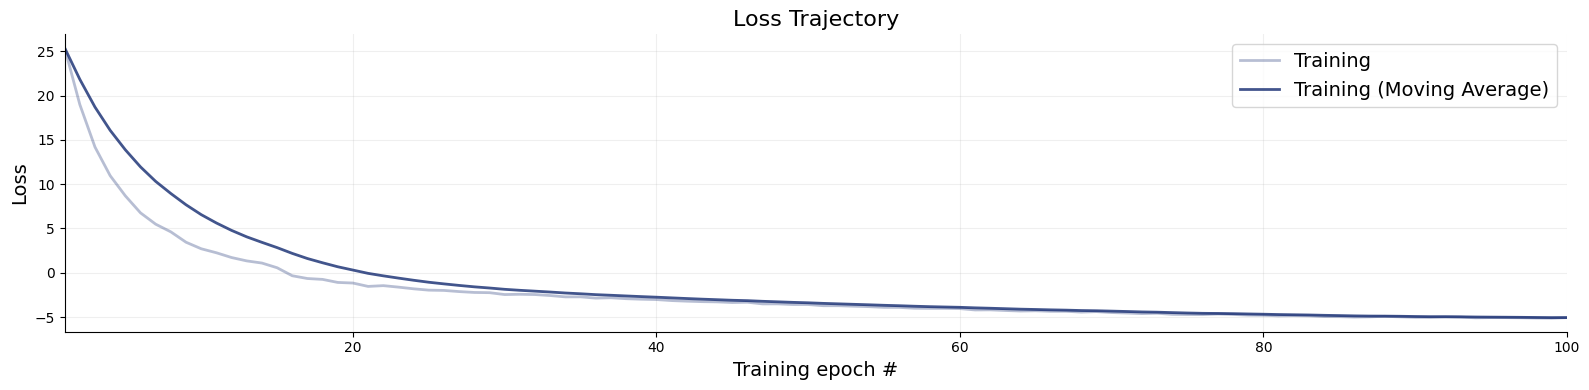

In [15]:
f=bf.diagnostics.plots.loss(history)

In [ ]:
# Generate test datasets and get posterior samples and perform diagnostics
num_samples = 1000 #number of posterior samples
val_sims = simulator.sample(200) # validation data
post_draws = workflow.sample(conditions=val_sims, num_samples=num_samples)
post_draws.keys()

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

dict_keys(['mu'])

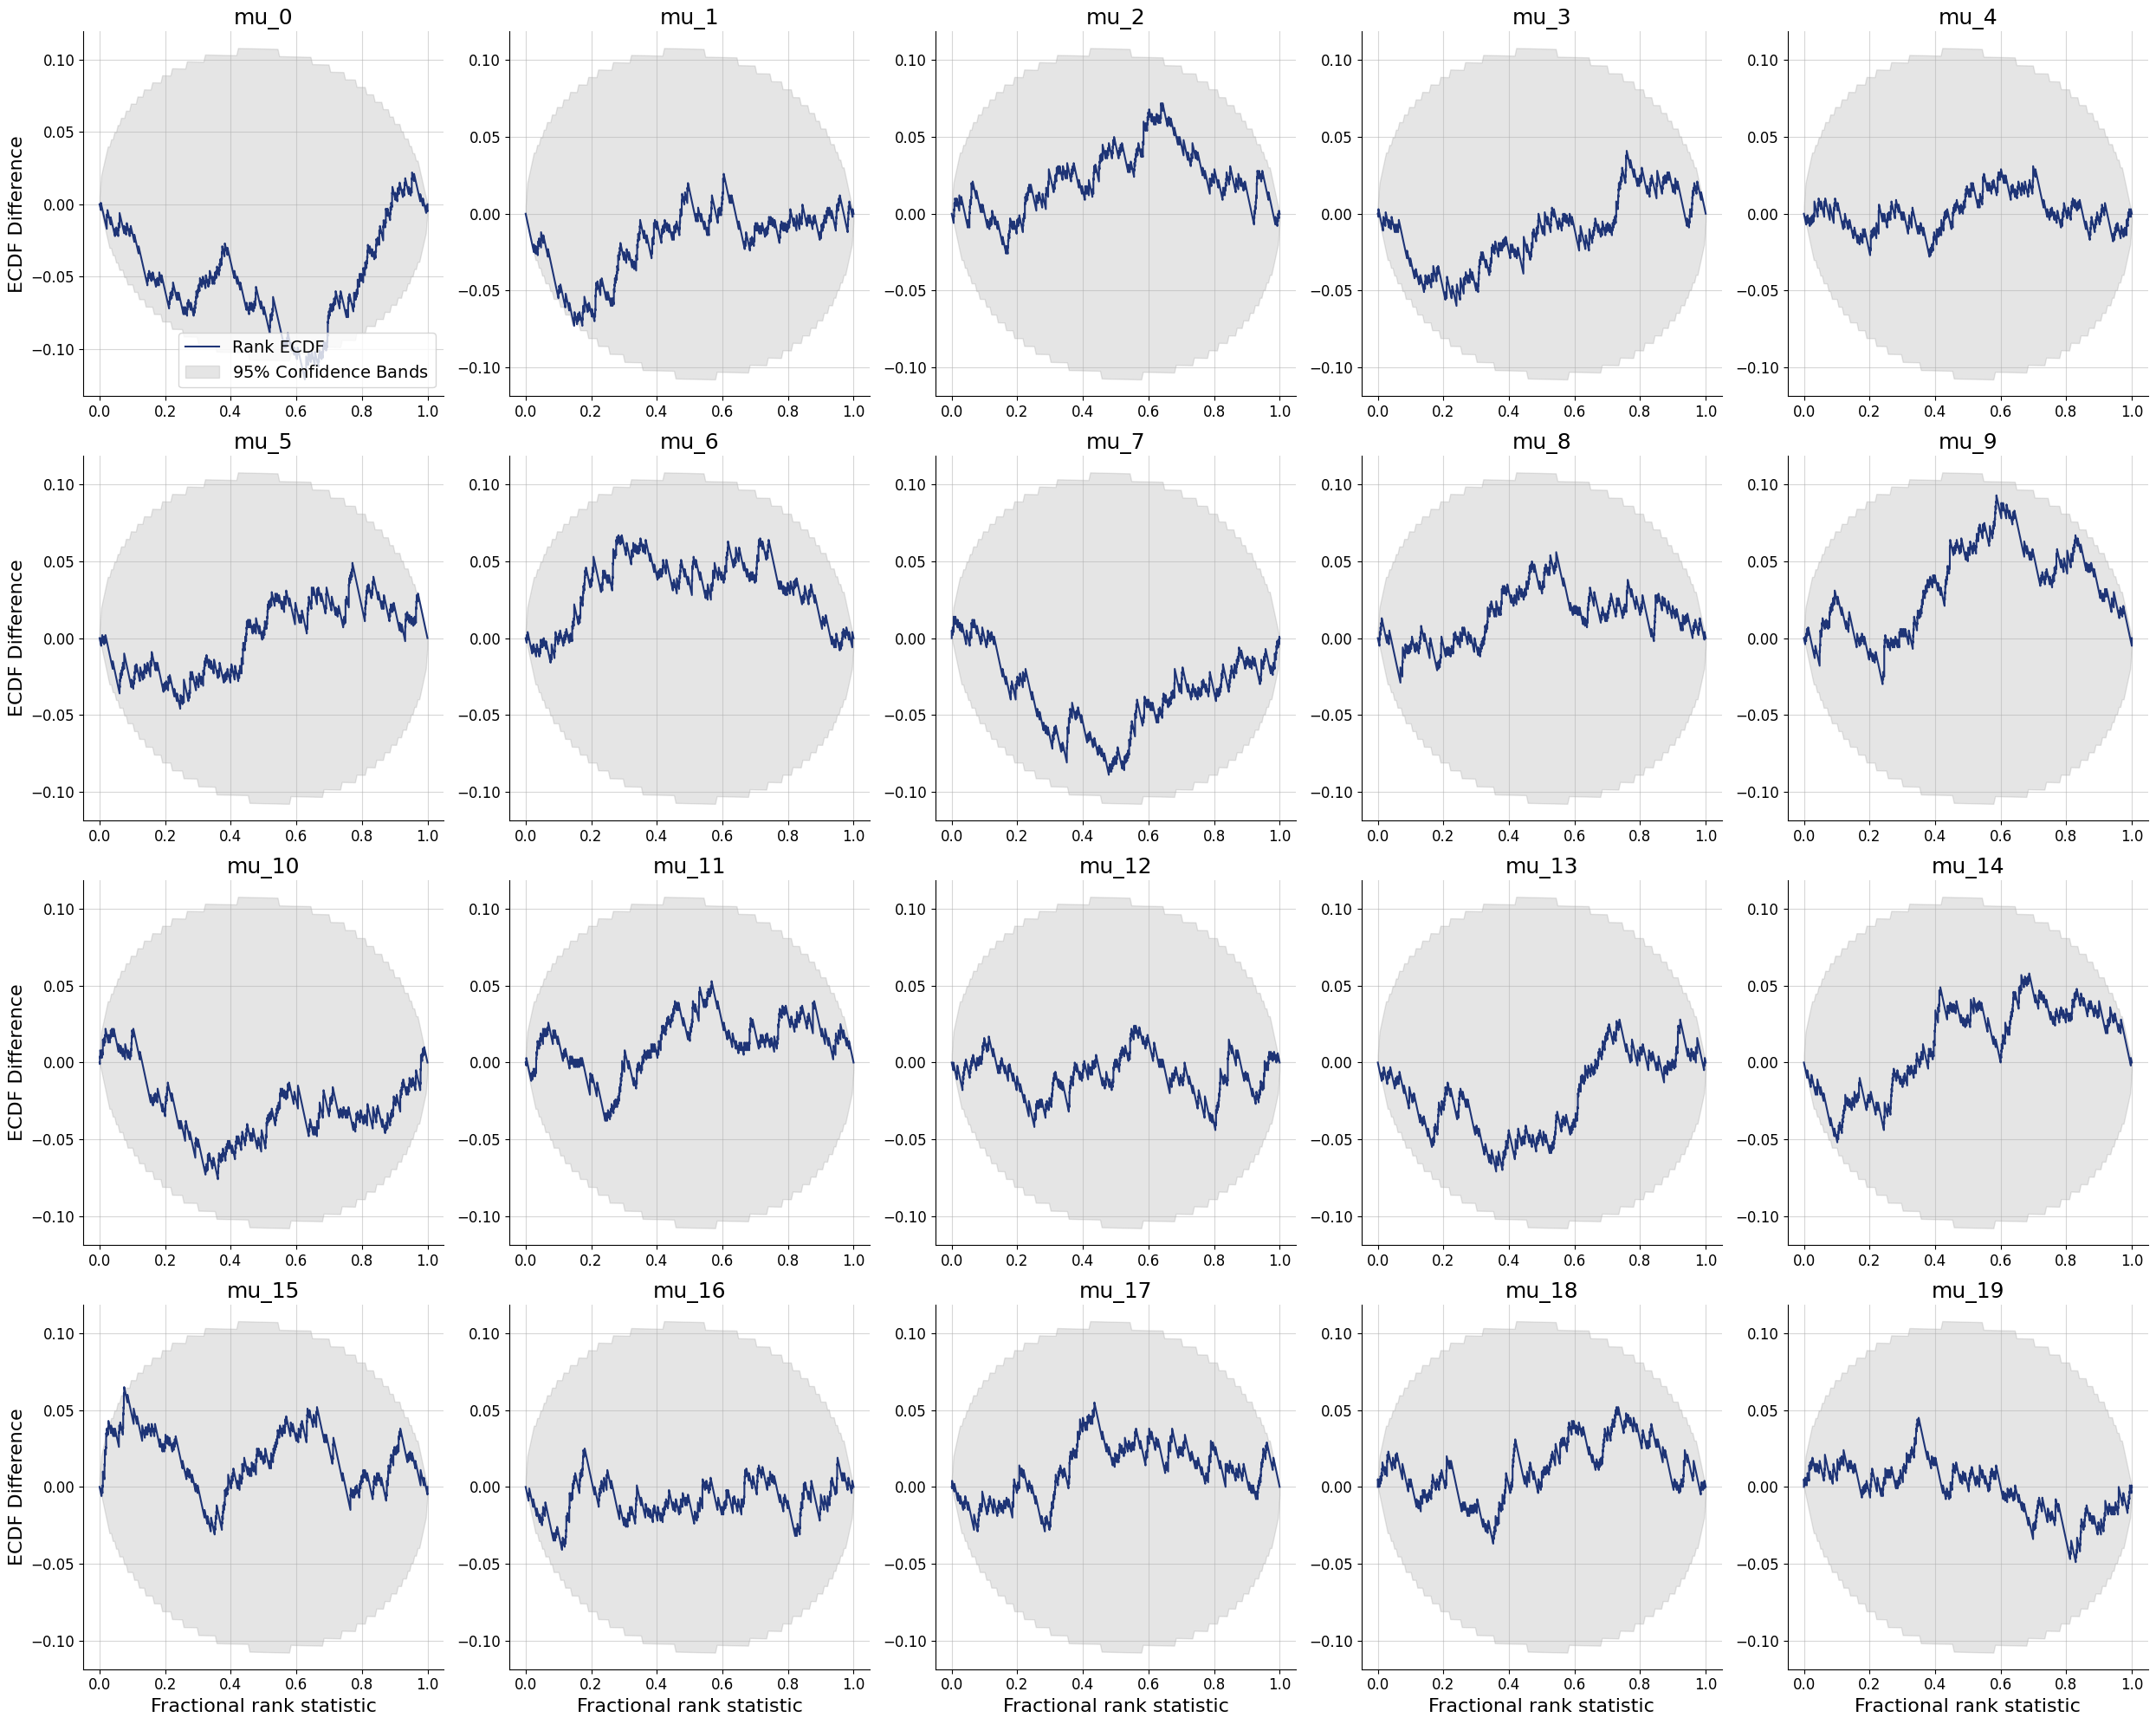

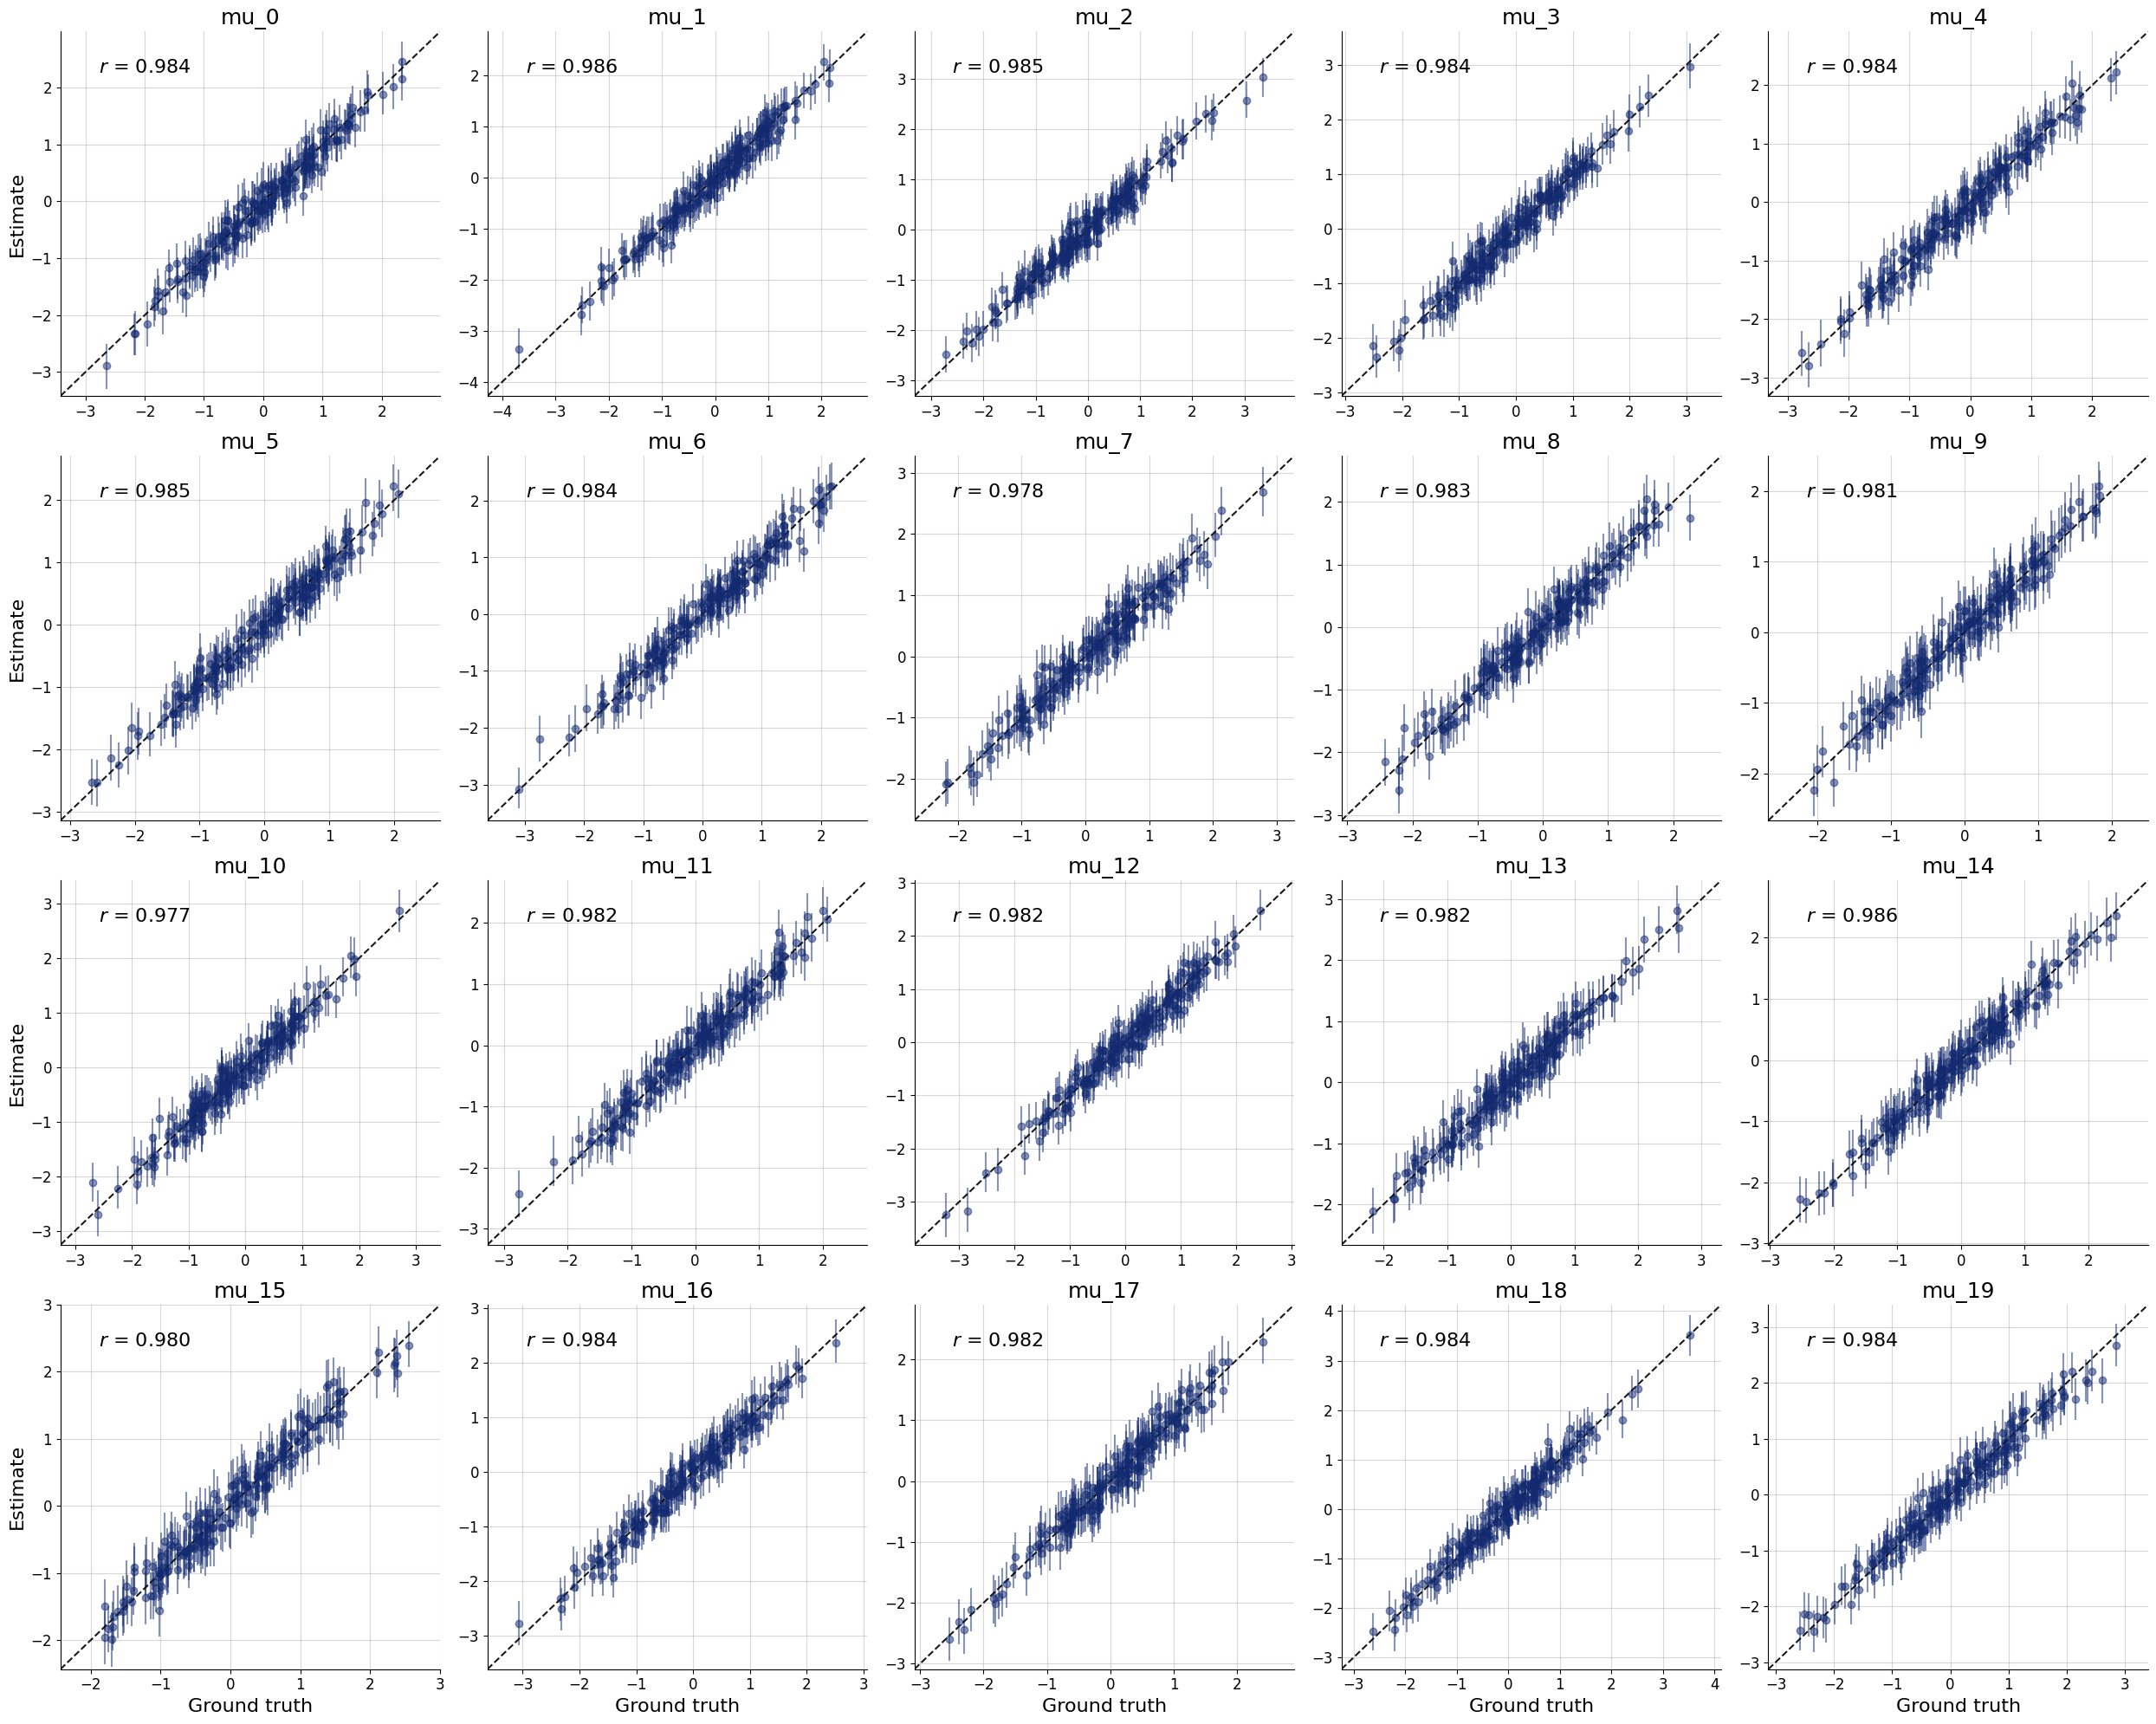

In [17]:
#f1 = bf.diagnostics.plots.calibration_histogram(post_draws, val_sims)
f2 = bf.diagnostics.plots.calibration_ecdf(post_draws, val_sims,difference=True)
f3 = bf.diagnostics.plots.recovery(post_draws, val_sims)

In [18]:
# Save the trained approximator
filepath = Path("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/networks") / "m3.keras"
filepath.parent.mkdir(exist_ok=True)
workflow.approximator.save(filepath=filepath)

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

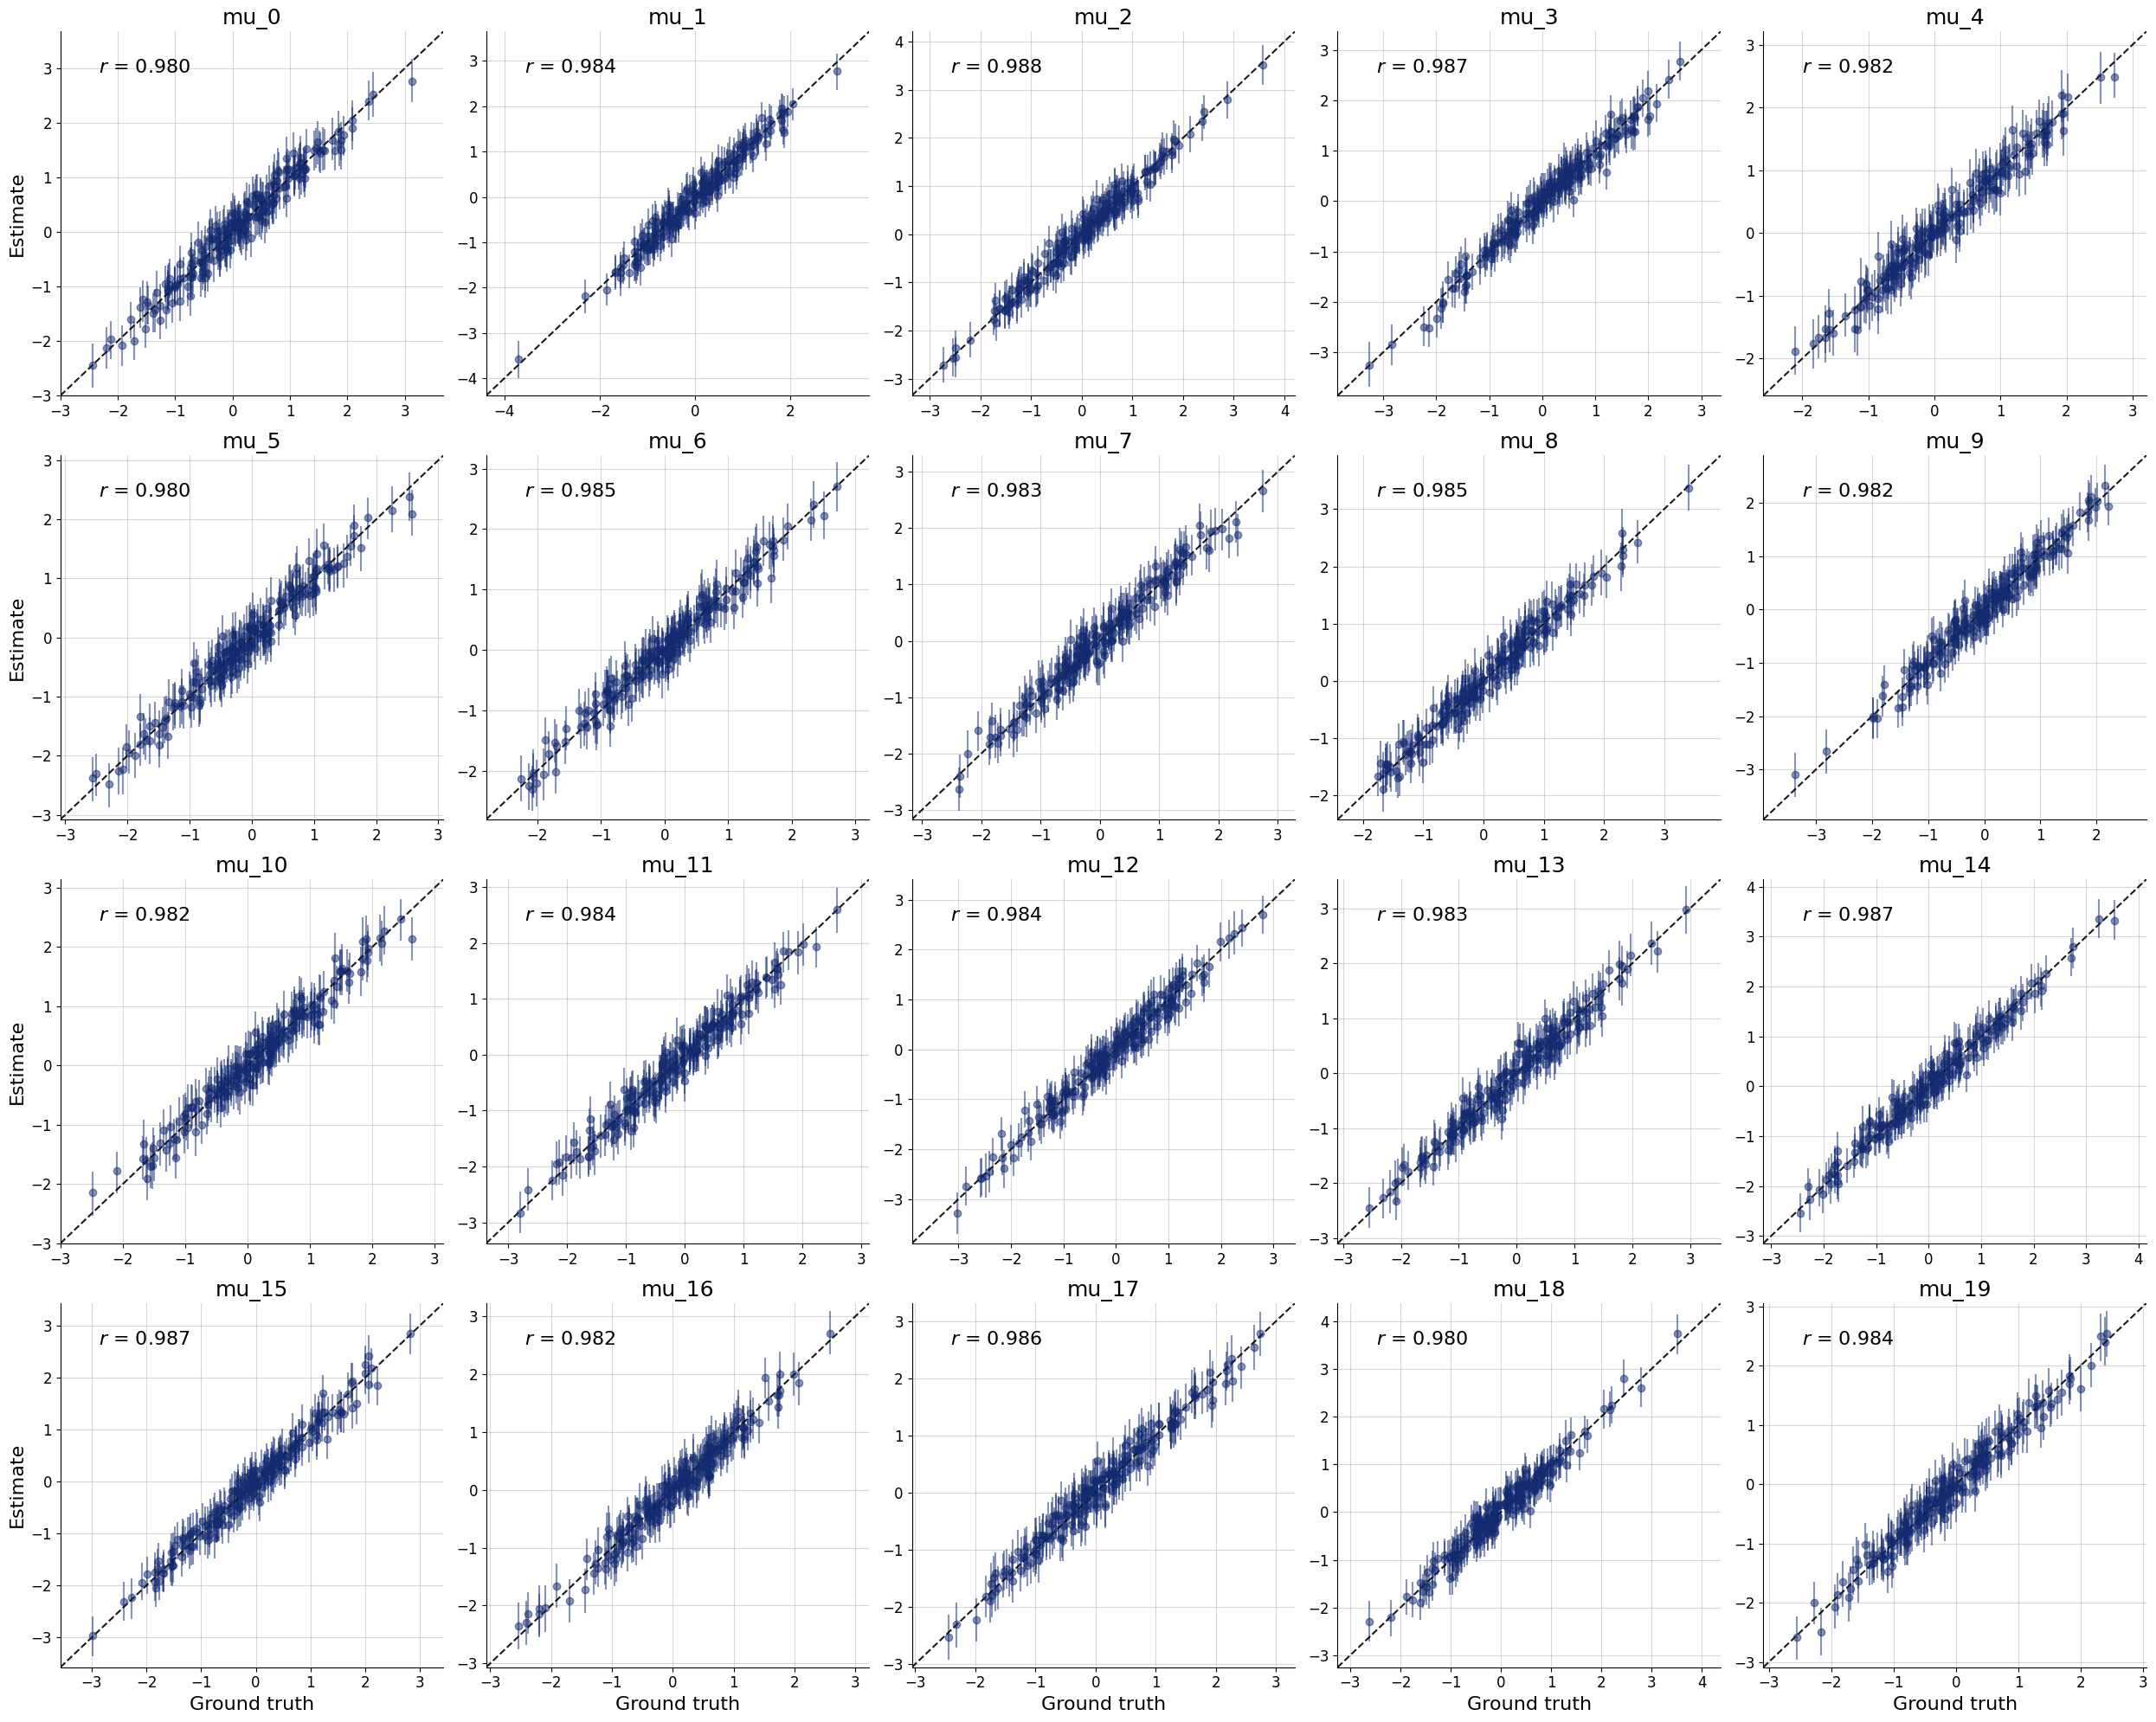

In [8]:
# load approximator
filepath = Path("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/networks") / "m3.keras"
approximator = keras.saving.load_model(filepath)
post_draws = approximator.sample(conditions=val_sims, num_samples=num_samples)
f3 = bf.diagnostics.plots.recovery(post_draws, val_sims)

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

,label,n,ood_rate,"Median d_M [2.5%, 97.5%]","Median signed_logml_error_m1 [2.5%, 97.5%]"
0,M1 (well_specified),256,0.093750,"10.098 [7.737, 15.232]","-0.000 [-0.048, 0.044]"
1,M2 (prior misspecification),256,0.332031,"11.752 [8.323, 18.633]","-0.001 [-0.060, 0.064]"
2,M3 (likelihood misspecification),256,0.089844,"9.389 [6.285, 14.291]","-0.025 [-0.628, 0.374]"
3,M4 (open_world),256,1.000000,"31.659 [21.057, 43.023]","-3.551 [-21.831, 0.575]"


(<Figure size 1400x500 with 2 Axes>,
 array([<Axes: title={'center': 'Per-dataset relationship'}, xlabel='Summary-space OOD score $d_M$', ylabel='signed_logml_error_m1'>,
        <Axes: title={'center': 'Group-level relationship'}, xlabel='Median $d_M$ with empirical 95% interval', ylabel='Median signed_logml_error_m1 with empirical 95% interval'>],
       dtype=object))

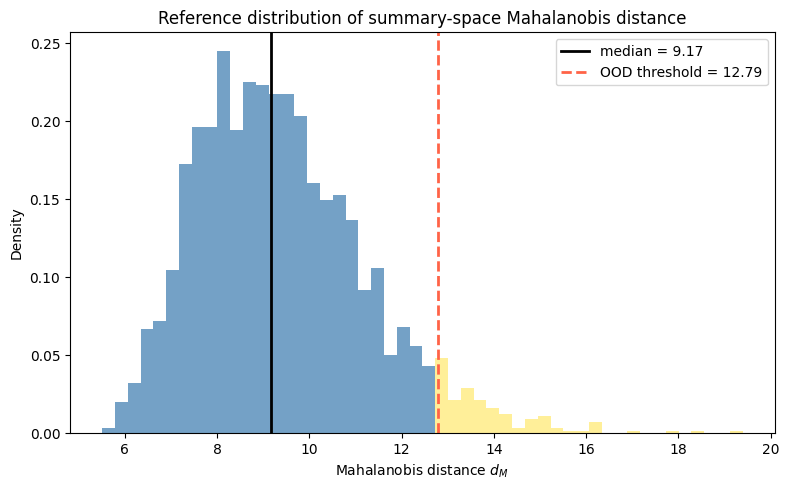

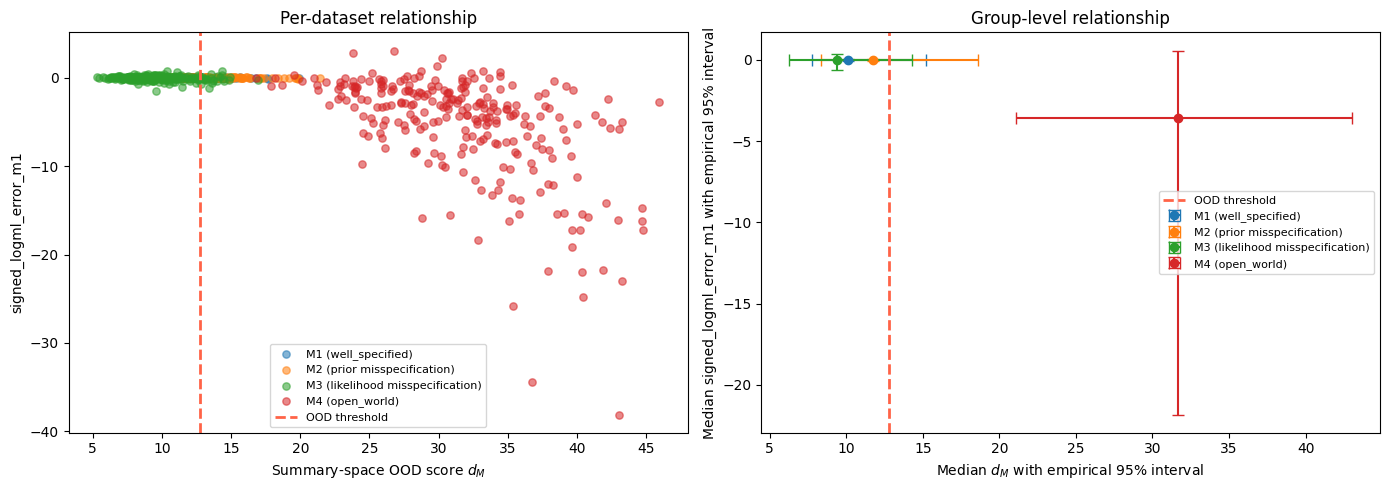

In [9]:
dataset_dir = Path("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian/results/datasets")
ref = sd.fit_reference(approximator, simulator, n_ref=2000)

sd.plot_reference(ref)
df_logml = sd.collect_metric_relation(
    approximator,
    dataset_dir,
    ref,
    sources=["m1", "m2", "m3", "m4"],
    metric_fn=sd.signed_logml_error("m1"),
    metric_name="signed_logml_error_m1",
)
labels = {
    "m1": "M1 (well_specified)",
    "m2": "M2 (prior misspecification)",
    "m3": "M3 (likelihood misspecification)",
    "m4": "M4 (open_world)",
}
summary = sd.empirical_summary(df_logml, "signed_logml_error_m1", labels=labels)
display(sd.format_summary(summary, "signed_logml_error_m1"))

sd.plot_metric_relation(df_logml, summary, "signed_logml_error_m1", ref, labels=labels)